<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/session06-gradient-descent-xor.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Session 6 — Linear models, gradient descent, and the XOR problem {.unnumbered}

This notebook follows the argument of the Session 6 page, and its
section numbers are the page's:

2. **Learning weights:** a least-squares solver and gradient descent find the same line.
3. **What one weighted sum can do:** AND, OR and NAND with the page's weights, every corner computed, and AND learned by gradient descent.
4. **What it can never do:** the same model trained on XOR gives up, and a search over thousands of weights finds none that work.
5. **Why a hidden layer helps:** the page's two-layer network computed step by step; a small network learns XOR, with the shape of every tensor printed; without its nonlinear activation it fails again.
6. **Changing the input, and a real protein:** one engineered feature makes XOR linear; *HBB*'s per-residue secondary structure against its composition.

No training-loop abstractions are used on purpose: Session 8 introduces `nn.Module` and the idiomatic training loop. Here, the mechanics are the point.

In [1]:
import torch
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)

# The four corners of the unit square are our whole "dataset" for both logic functions
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_and = torch.tensor([0., 0., 0., 1.])
y_xor = torch.tensor([0., 1., 1., 0.])

## 2. Learning weights: linear regression, two ways

Before perceptrons, one more contrast on the simplest possible model.
Ordinary linear regression has a direct numerical solution (least
squares), so the same weights can be found two ways: solved for directly,
or learned iteratively by gradient descent. Both should agree.
(`np.linalg.lstsq` solves least squares with stable numerical methods;
the textbook formula with an explicit matrix inverse, the normal
equations, is on the page as optional reading.)

In [2]:
x_reg = np.array([1., 2., 3., 4., 5.])
y_reg = np.array([2.1, 3.9, 6.2, 7.8, 10.1])

# --- direct solution: least squares ---
X_reg = np.column_stack([np.ones_like(x_reg), x_reg])
beta_direct, *_ = np.linalg.lstsq(X_reg, y_reg, rcond=None)
print("least squares    b0, b1:", np.round(beta_direct, 4))

# --- gradient descent on the exact same data ---
b0, b1 = 0.0, 0.0
lr = 0.01
for _ in range(20000):
    pred = b0 + b1 * x_reg
    err = pred - y_reg
    grad_b0 = 2 * np.mean(err)
    grad_b1 = 2 * np.mean(err * x_reg)
    b0 -= lr * grad_b0
    b1 -= lr * grad_b1
print("gradient descent  b0, b1:", np.round([b0, b1], 4))

least squares    b0, b1: [0.05 1.99]


gradient descent  b0, b1: [0.05 1.99]


Same answer, found two different ways: the least-squares solver finds
the minimum directly; gradient descent gets there gradually, step by step.
Session 5's PSSM weights are "derived" in this direct spirit (counted from
alignment statistics); a perceptron's classification loss has no direct
solution, which is why the rest of this notebook learns its weights by
gradient descent.

## 3. What one weighted sum can do

A single perceptron with a step activation implements AND, OR and NAND
with hand-chosen weights: each is one straight boundary through the
square of four inputs. The cell below uses exactly the weights of the
page's table and prints $z$ and the output for every corner. Then
gradient descent learns AND by itself.

In [3]:
def hand_perceptron(w1, w2, b, x1, x2):
    z = w1 * x1 + w2 * x2 + b
    return 1 if z > 0 else 0

corners = [(0, 0), (0, 1), (1, 0), (1, 1)]

gates = {
    "AND":  (1, 1, -1.5),
    "OR":   (1, 1, -0.5),
    "NAND": (-1, -1, 1.5),
}
targets = {
    "AND":  [0, 0, 0, 1],
    "OR":   [0, 1, 1, 1],
    "NAND": [1, 1, 1, 0],
}
for name, (w1, w2, b) in gates.items():
    print(f"{name}: z = {w1:+d}*x1 {w2:+d}*x2 {b:+.1f}")
    print("   x1  x2      z   output")
    for x1, x2 in corners:
        z = w1 * x1 + w2 * x2 + b
        print(f"   {x1:2d}  {x2:2d}  {z:+5.1f}   {hand_perceptron(w1, w2, b, x1, x2)}")
    outputs = [hand_perceptron(w1, w2, b, x1, x2) for x1, x2 in corners]
    print(f"   matches the {name} truth table {targets[name]}: {outputs == targets[name]}\n")

AND: z = +1*x1 +1*x2 -1.5
   x1  x2      z   output
    0   0   -1.5   0
    0   1   -0.5   0
    1   0   -0.5   0
    1   1   +0.5   1
   matches the AND truth table [0, 0, 0, 1]: True

OR: z = +1*x1 +1*x2 -0.5
   x1  x2      z   output
    0   0   -0.5   0
    0   1   +0.5   1
    1   0   +0.5   1
    1   1   +1.5   1
   matches the OR truth table [0, 1, 1, 1]: True

NAND: z = -1*x1 -1*x2 +1.5
   x1  x2      z   output
    0   0   +1.5   1
    0   1   +0.5   1
    1   0   +0.5   1
    1   1   -0.5   0
   matches the NAND truth table [1, 1, 1, 0]: True



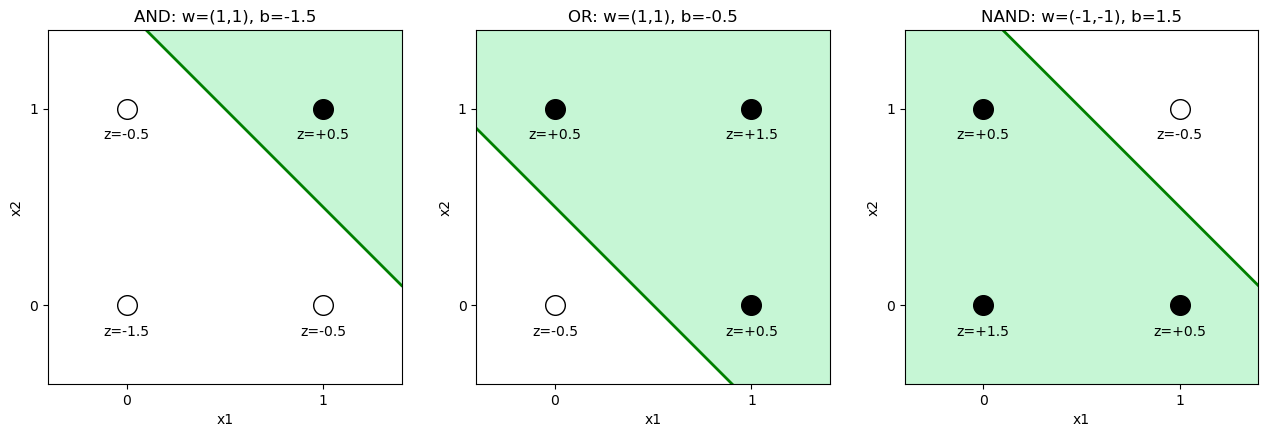

In [4]:
# The page's figure: each gate is one straight line, z = 0, with the output-1 corners on the side where z > 0
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
xx, yy = np.meshgrid(np.linspace(-0.4, 1.4, 200), np.linspace(-0.4, 1.4, 200))
for ax, (name, (w1, w2, b)) in zip(axes, gates.items()):
    ax.contourf(xx, yy, w1 * xx + w2 * yy + b > 0, levels=[-0.5, 0.5, 1.5], colors=["white", "#c6f6d5"])
    xs = np.array([-0.4, 1.4])
    ax.plot(xs, -(w1 * xs + b) / w2, color="green", lw=2)          # the line w1*x1 + w2*x2 + b = 0
    for x1, x2 in corners:
        out = hand_perceptron(w1, w2, b, x1, x2)
        ax.scatter(x1, x2, s=200, edgecolor="k", color="k" if out else "white", zorder=3)
        ax.annotate(f"z={w1 * x1 + w2 * x2 + b:+.1f}", (x1, x2), xytext=(0, -22), textcoords="offset points",
                    ha="center")
    ax.set_title(f"{name}: w=({w1},{w2}), b={b}")
    ax.set_xlim(-0.4, 1.4); ax.set_ylim(-0.4, 1.4); ax.set_aspect("equal")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1]); ax.set_xlabel("x1"); ax.set_ylabel("x2")
plt.tight_layout()
plt.show()

### AND, learned by gradient descent

In [5]:
def train_linear(X, y, lr=0.5, epochs=300, track_every=50):
    w = torch.zeros(2, requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    losses = []
    for epoch in range(epochs):
        z = X @ w + b
        pred = torch.sigmoid(z)
        loss = torch.nn.functional.binary_cross_entropy(pred, y)
        loss.backward()
        with torch.no_grad():
            w -= lr * w.grad
            b -= lr * b.grad
            w.grad.zero_()
            b.grad.zero_()
        if epoch % track_every == 0:
            losses.append(loss.item())
    with torch.no_grad():
        final_pred = torch.sigmoid(X @ w + b)
    return w.detach(), b.detach(), losses, final_pred

w_and, b_and, losses_and, pred_and = train_linear(X, y_and)
print("learned weights:", w_and.numpy(), "bias:", b_and.numpy())
print("target:         ", y_and.numpy())
print("predicted:      ", np.round(pred_and.numpy(), 3))

learned weights: [3.7240057 3.7240057] bias: [-5.786265]
target:          [0. 0. 0. 1.]
predicted:       [0.003 0.113 0.113 0.84 ]


The predictions land close to 0 for the three "false" corners and close to 1 for `(1,1)` — the linear model finds a straight line that separates AND's two classes without any trouble, as Session 1's perceptron discussion would predict for a linearly separable function.

## 4. What it can never do: XOR

In [6]:
w_xor, b_xor, losses_xor, pred_xor = train_linear(X, y_xor, epochs=2000)
print("learned weights:", w_xor.numpy(), "bias:", b_xor.numpy())
print("target:         ", y_xor.numpy())
print("predicted:      ", np.round(pred_xor.numpy(), 3))
print("final loss:     ", round(losses_xor[-1], 4), " (ln(2) =", round(np.log(2), 4), "— i.e. no better than guessing 0.5 for everything)")

learned weights: [0. 0.] bias: [0.]
target:          [0. 1. 1. 0.]
predicted:       [0.5 0.5 0.5 0.5]
final loss:      0.6931  (ln(2) = 0.6931 — i.e. no better than guessing 0.5 for everything)


Every prediction converges to exactly 0.5 — the model has given up and is guessing. No choice of two weights and a bias can separate XOR's diagonal pattern with a straight line, so gradient descent has nowhere better to go. This is the same limitation Bulyk, Johnson & Church (2002) documented for real transcription-factor binding sites: a linear/profile score cannot represent an effect that depends on the *combination* of two positions rather than each independently.

The page asks you to try to find weights for XOR by hand. The cell
below tries for you: every combination of $w_1$, $w_2$ and $b$ on a grid
from −3 to 3 in steps of 0.1, over 200,000 perceptrons, and counts how
many reproduce each truth table.

In [7]:
grid = np.round(np.arange(-3, 3.01, 0.1), 1)
W1, W2, B = np.meshgrid(grid, grid, grid, indexing="ij")
corners_np = np.array(corners)
# outputs of every perceptron on the grid, at all four corners: shape (61, 61, 61, 4)
out = ((W1[..., None] * corners_np[:, 0] + W2[..., None] * corners_np[:, 1] + B[..., None]) > 0).astype(int)
tables = {**targets, "XOR": [0, 1, 1, 0]}
print(f"{W1.size:,} perceptrons tried")
for name, target in tables.items():
    print(f"  {name:5s} {target}: reproduced by {int((out == target).all(axis=-1).sum()):,} of them")

226,981 perceptrons tried
  AND   [0, 0, 0, 1]: reproduced by 5,012 of them
  OR    [0, 1, 1, 1]: reproduced by 9,455 of them
  NAND  [1, 1, 1, 0]: reproduced by 4,467 of them
  XOR   [0, 1, 1, 0]: reproduced by 0 of them


Thousands of weight choices implement AND, OR or NAND: any line that
cuts off the right corners will do. Not a single one implements XOR, as
the page's geometric argument (and the optional proof) says.

## 5. Why a hidden layer helps

One perceptron draws one line; XOR needs two. The page's network feeds
the outputs of an OR perceptron and a NAND perceptron into an AND
perceptron. Written as matrices (one column of $W_1$ per hidden unit),
with the four input rows stacked into $X$:

$$
W_1 = \begin{pmatrix} 1 & -1 \\ 1 & -1 \end{pmatrix},\quad
\mathbf{b}_1 = (-0.5,\ 1.5),\quad
W_2 = \begin{pmatrix} 1 \\ 1 \end{pmatrix},\quad
b_2 = -1.5
$$

The cell computes every step for all four inputs at once, exactly as
the page's step-by-step table does.

In [8]:
step = lambda z: (z > 0).float()          # the step activation: 1 if z > 0, else 0

W1 = torch.tensor([[1., -1.],               # column 1: the OR unit, column 2: the NAND unit
                   [1., -1.]])
b1 = torch.tensor([-0.5, 1.5])
W2 = torch.tensor([[1.],                    # the AND unit, reading the two hidden units
                   [1.]])
b2 = torch.tensor([-1.5])

Z1 = X @ W1 + b1            # (4, 2): weighted sums of the two hidden units
H = step(Z1)                # (4, 2): hidden outputs, h1 = OR, h2 = NAND
z2 = H @ W2 + b2            # (4, 1): weighted sum of the output unit
y_hat = step(z2)            # (4, 1): the network's output

print("  x1 x2 |  z_h1  h1   z_h2  h2 |  z_out  y | XOR")
for (x1, x2), (za, zb), (ha, hb), zo, yo, t in zip(X.int().tolist(), Z1.tolist(), H.int().tolist(),
                                                   z2.squeeze(1).tolist(), y_hat.int().squeeze(1).tolist(),
                                                   y_xor.int().tolist()):
    print(f"   {x1}  {x2} | {za:+5.1f}  {ha}   {zb:+5.1f}  {hb} |  {zo:+5.1f}  {yo} |  {t}")
print("\nnetwork output equals XOR:", torch.equal(y_hat.squeeze(1), y_xor))
xor_by_hand = y_hat.int().squeeze(1).tolist()

  x1 x2 |  z_h1  h1   z_h2  h2 |  z_out  y | XOR
   0  0 |  -0.5  0    +1.5  1 |   -0.5  0 |  0
   0  1 |  +0.5  1    +0.5  1 |   +0.5  1 |  1
   1  0 |  +0.5  1    +0.5  1 |   +0.5  1 |  1
   1  1 |  +1.5  1    -0.5  0 |   -0.5  0 |  0

network output equals XOR: True


Exact, with no training at all: two perceptrons (OR and NAND) form a
hidden layer, and a third perceptron (AND) combines their outputs into
XOR. This is the same *shape* -- two hidden units feeding one output
unit -- as the hidden-layer network below finds automatically by
gradient descent; the hand-built version just proves such weights exist
and shows concretely what they look like.

### A small network learns XOR

In [9]:
def train_mlp(X, y, hidden=2, lr=0.5, epochs=5000, seed=0, activation=torch.tanh, show_shapes=False):
    torch.manual_seed(seed)
    W1 = torch.randn(2, hidden, requires_grad=True)
    b1 = torch.zeros(hidden, requires_grad=True)
    W2 = torch.randn(hidden, 1, requires_grad=True)
    b2 = torch.zeros(1, requires_grad=True)
    params = [W1, b1, W2, b2]
    y = y.view(-1, 1)                          # targets as a column: shape (4, 1)
    losses = []
    for epoch in range(epochs):
        h = activation(X @ W1 + b1)            # (4, 2) @ (2, 2) -> (4, 2)
        z = h @ W2 + b2                        # (4, 2) @ (2, 1) -> (4, 1)
        pred = torch.sigmoid(z)
        loss = torch.nn.functional.binary_cross_entropy(pred, y)
        if show_shapes and epoch == 0:
            for name, t in [("X", X), ("W1", W1), ("h", h), ("W2", W2), ("pred", pred)]:
                print(f"{name:5s} shape {tuple(t.shape)}")
        loss.backward()
        with torch.no_grad():
            for p in params:
                p -= lr * p.grad
                p.grad.zero_()
        if epoch % 500 == 0:
            losses.append(loss.item())
    with torch.no_grad():
        final_pred = torch.sigmoid(activation(X @ W1 + b1) @ W2 + b2)
    return losses, final_pred.flatten()

losses_mlp, pred_mlp = train_mlp(X, y_xor, seed=0, show_shapes=True)
print("\ntarget:     ", y_xor.numpy())
print("predicted:  ", np.round(pred_mlp.numpy(), 3))
print("final loss: ", round(losses_mlp[-1], 4))

X     shape (4, 2)
W1    shape (2, 2)
h     shape (4, 2)
W2    shape (2, 1)
pred  shape (4, 1)



target:      [0. 1. 1. 0.]
predicted:   [0.001 0.998 0.998 0.001]
final loss:  0.0014


With just two hidden units, the network finds a solution — each hidden unit learns its own linear boundary, and combining them lets the output represent XOR's non-linear pattern. (With only two hidden units, not every random initialization finds this solution — some get stuck in a symmetric local minimum where the two hidden units learn identical, redundant boundaries. Try re-running `train_mlp` with a different `seed` to see this happen; it's a genuine, well-known property of small networks, not a bug in this notebook.)

### Remove the nonlinearity, and the hidden layer is useless

The same network, with the `tanh` activation replaced by the identity
(`lambda t: t`): the hidden layer is now just another weighted sum, and
two weighted sums in a row are one weighted sum,
$W_2(W_1 x + b_1) + b_2 = (W_2 W_1)x + (W_2 b_1 + b_2)$. Predict what
happens before running it.

In [10]:
losses_lin, pred_lin = train_mlp(X, y_xor, seed=0, activation=lambda t: t)
print("target:     ", y_xor.numpy())
print("predicted:  ", np.round(pred_lin.numpy(), 3))
print("final loss: ", round(losses_lin[-1], 4), "(ln 2 = 0.6931: no better than guessing 0.5)")

target:      [0. 1. 1. 0.]
predicted:   [0.5 0.5 0.5 0.5]
final loss:  0.6931 (ln 2 = 0.6931: no better than guessing 0.5)


Every prediction is 0.5 again, exactly like the linear model in Section 4.
Without a nonlinear activation, the extra layer adds parameters but no new
kinds of functions. The `tanh` between the layers is what makes the hidden
layer able to solve XOR.

### Visualizing why: the decision boundary

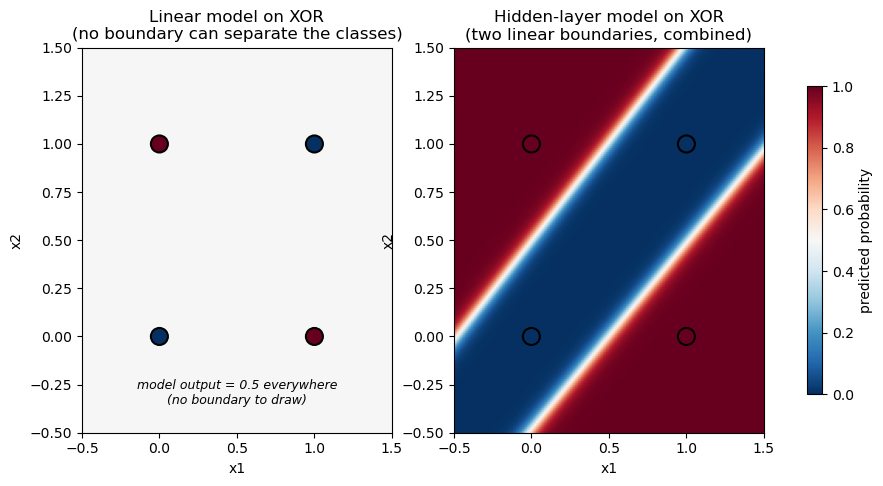

In [11]:
def plot_boundary(ax, predict_fn, title, annotate_flat=False):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        zz = predict_fn(grid).numpy().reshape(xx.shape)
    im = ax.imshow(zz, extent=(-0.5, 1.5, -0.5, 1.5), origin="lower", cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
    ax.scatter(X[:, 0], X[:, 1], c=y_xor, cmap="RdBu_r", edgecolor="black", linewidth=1.5, s=150, vmin=0, vmax=1)
    if annotate_flat:
        ax.text(0.5, -0.35, "model output = 0.5 everywhere\n(no boundary to draw)", ha="center", fontsize=9, style="italic")
    ax.set_title(title)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    return im

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
im0 = plot_boundary(axes[0], lambda g: torch.sigmoid(g @ w_xor + b_xor), "Linear model on XOR\n(no boundary can separate the classes)", annotate_flat=True)

# retrain the seed-0 hidden-layer model once more, keeping the raw parameters
# (not just its predictions) so we can reuse them in the plotting closure below
torch.manual_seed(0)
W1 = torch.randn(2, 2, requires_grad=True); b1 = torch.zeros(2, requires_grad=True)
W2 = torch.randn(2, 1, requires_grad=True); b2 = torch.zeros(1, requires_grad=True)
params = [W1, b1, W2, b2]
for epoch in range(5000):
    h = torch.tanh(X @ W1 + b1)
    z = h @ W2 + b2
    pred = torch.sigmoid(z)
    loss = torch.nn.functional.binary_cross_entropy(pred, y_xor.view(-1, 1))
    loss.backward()
    with torch.no_grad():
        for p in params:
            p -= 0.5 * p.grad
            p.grad.zero_()

def mlp_predict(g):
    h = torch.tanh(g @ W1.detach() + b1.detach())
    return torch.sigmoid(h @ W2.detach() + b2.detach())

im1 = plot_boundary(axes[1], mlp_predict, "Hidden-layer model on XOR\n(two linear boundaries, combined)")
fig.colorbar(im1, ax=axes, shrink=0.8, label="predicted probability")
plt.show()

The left panel shows why the linear model gave up: the two "true" corners `(0,1)` and `(1,0)` sit on opposite sides of the square from each other, so they can't be put on one side of any single straight line while the two "false" corners sit on the other. The right panel shows the hidden-layer model's solution: it combines two different linear boundaries (one per hidden unit) into a region that correctly isolates the two "true" corners — the extra representational power a hidden layer buys you, and what Session 9 uses to build a real secondary-structure predictor.

## 6a. Changing the input instead

A hidden layer isn't the only way to rescue a linear model on XOR: a better *input* works too. For
0/1-valued inputs, $\text{XOR}(x_1, x_2) = x_1 + x_2 - 2 x_1 x_2$
exactly -- so adding $x_1 x_2$ as a third input turns XOR back into
something an ordinary linear model (even plain linear regression, not a
perceptron) can fit exactly.

In [12]:
X_xor_raw = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_xor_np = np.array([0., 1., 1., 0.])

# engineer the interaction feature by hand
interaction = X_xor_raw[:, 0] * X_xor_raw[:, 1]
X_xor_engineered = np.column_stack([X_xor_raw, interaction])

weights_by_hand = np.array([1., 1., -2.])
bias_by_hand = 0.
pred_engineered = X_xor_engineered @ weights_by_hand + bias_by_hand

print("inputs (x1, x2, x1*x2):")
print(X_xor_engineered)
print("predicted:", pred_engineered)
print("target:   ", y_xor_np)
print("exact match:", np.allclose(pred_engineered, y_xor_np))

inputs (x1, x2, x1*x2):
[[0. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 1. 1.]]
predicted: [0. 1. 1. 0.]
target:    [0. 1. 1. 0.]
exact match: True


An exact fit, with plain linear weights $(1, 1, -2)$ and zero bias --
once someone has already noticed that $x_1 x_2$ is the feature that
matters. The model did not change; only the *input* did. That "someone
has to notice" is the catch: for Bulyk et al.'s real transcription-factor
data, or for secondary structure, nobody knows the useful interaction
terms in advance. A hidden layer's advantage is that it *learns* features
like this from data.

The lesson reaches beyond XOR: what a model can learn depends on what
its input represents. No model, however large, can recover information
the input does not contain. The lab makes the same point with real
proteins.

## 6b. Two views of a real protein: HBB

A secondary-structure predictor has to label *every residue*. Fetch the
labels of *HBB* (beta-globin, chain B of the human hemoglobin crystal
structure `2HHB`) from EBI's PDBe API, and compare two ways of
presenting this protein to a model: a window of neighbouring residues
(what PHD reads) and the 20 amino-acid fractions (what the lab uses).

In [13]:
import requests

base = "https://www.ebi.ac.uk/pdbe/api/pdb/entry"
entry = requests.get(f"{base}/secondary_structure/2hhb", timeout=10).json()["2hhb"]
molecules = requests.get(f"{base}/molecules/2hhb", timeout=10).json()["2hhb"]

# HBB (beta-globin) is chain B; its sequence comes from the structure itself
seq = next(m["sequence"] for m in molecules if "B" in m.get("in_chains", []) and m.get("length"))
chain = next(c for m in entry["molecules"] for c in m["chains"] if c["chain_id"] == "B")
helices = chain["secondary_structure"]["helices"]
strands = chain["secondary_structure"].get("strands", [])

labels = ["C"] * len(seq)                      # C = coil, H = helix
for h in helices:
    for r in range(h["start"]["residue_number"], h["end"]["residue_number"] + 1):
        labels[r - 1] = "H"
labels = "".join(labels)

print("View 1, per residue: the sequence and the label a predictor must produce")
for start in range(0, len(seq), 50):
    print(f"{start + 1:4d}  {seq[start:start + 50]}")
    print(f"      {labels[start:start + 50]}")
print(f"\n{labels.count('H')} of {len(seq)} residues in a helix ({labels.count('H') / len(seq):.0%}), "
      f"{len(strands)} strands")

centre, half = 63, 6                           # a PHD-style window of 13 residues around His63
window = seq[centre - 1 - half:centre + half]
print(f"\nPHD-style input for residue {centre} ({seq[centre - 1]}): the window {window}, "
      f"target label {labels[centre - 1]}")

aas = "ACDEFGHIKLMNPQRSTVWY"
composition = [seq.count(a) / len(seq) for a in aas]
print("\nView 2, the lab's input: 20 fractions, the same for any order of these residues")
print("  " + "  ".join(f"{a}:{f:.3f}" for a, f in zip(aas, composition)))
print(f"  and one target: helix fraction = {labels.count('H') / len(seq):.2f}")

assert len(strands) == 0 and labels.count("H") == 117 and len(seq) == 146

View 1, per residue: the sequence and the label a predictor must produce
   1  VHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLST
      CCCCHHHHHHHHHHHCCCCHHHHHHHHHHHHHHHCHHHHHHCHHHCCCCC
  51  PDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDP
      HHHHHHCHHHHHHHHHHHHHHHHHHCCHHHHHHHHHHHHHHHHHHCCCCC
 101  ENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH
      HHHHHHHHHHHHHHHHHHHHHCCHHHHHHHHHHHHHHHHHHHCCCC

117 of 146 residues in a helix (80%), 0 strands

PHD-style input for residue 63 (H): the window NPKVKAHGKKVLG, target label H

View 2, the lab's input: 20 fractions, the same for any order of these residues
  A:0.103  C:0.014  D:0.048  E:0.055  F:0.055  G:0.089  H:0.062  I:0.000  K:0.075  L:0.123  M:0.007  N:0.041  P:0.048  Q:0.021  R:0.021  S:0.034  T:0.048  V:0.123  W:0.014  Y:0.021
  and one target: helix fraction = 0.80


View 1 keeps what matters for each label: which residues are
neighbours, in what order, and where helices start and stop. View 2
keeps only counts. A model given view 2 can at best predict the overall
fraction; it can never say *which* residues are helical. The lab builds
exactly such a model on 55 proteins.